# 🤖 AI Git Automation Agent - Graph Visualization

This notebook visualizes the LangGraph workflow with **TWO human approval steps**.

## Setup and Imports

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

load_dotenv()
print("✅ Imports successful!")

✅ Imports successful!


## Agent State Definition

In [2]:
class AgentState(TypedDict):
    has_changes: bool
    diff: str
    commit_message: str
    approved: bool
    committed: bool
    push_approved: bool
    pushed: bool
    error: str

print("State schema:")
for key, value in AgentState.__annotations__.items():
    print(f"  {key}: {value}")

State schema:
  has_changes: <class 'bool'>
  diff: <class 'str'>
  commit_message: <class 'str'>
  approved: <class 'bool'>
  committed: <class 'bool'>
  push_approved: <class 'bool'>
  pushed: <class 'bool'>
  error: <class 'str'>


## Node Functions (Simplified for Demo)

In [3]:
def detect_changes(state: AgentState) -> AgentState:
    print("🔍 Node: detect_changes")
    state["has_changes"] = True
    return state

def analyze_diff(state: AgentState) -> AgentState:
    print("📊 Node: analyze_diff")
    state["diff"] = "+ Added feature\n- Removed old code"
    return state

def generate_commit_message(state: AgentState) -> AgentState:
    print("🤖 Node: generate_commit_message")
    state["commit_message"] = "feat: add new feature and remove deprecated code"
    return state

def human_approval(state: AgentState) -> AgentState:
    print("✋ Node: human_approval (commit?)")
    state["approved"] = True  # Auto-approve for demo
    return state

def git_commit(state: AgentState) -> AgentState:
    print("💾 Node: git_commit")
    state["committed"] = True
    return state

def push_approval(state: AgentState) -> AgentState:
    print("✋ Node: push_approval (push?)")
    state["push_approved"] = True  # Auto-approve for demo
    return state

def git_push(state: AgentState) -> AgentState:
    print("🚀 Node: git_push")
    state["pushed"] = True
    return state

print("✅ Node functions defined!")

✅ Node functions defined!


## Build the LangGraph Workflow

In [4]:
def build_graph():
    workflow = StateGraph(AgentState)
    
    # Add all nodes
    workflow.add_node("detect_changes", detect_changes)
    workflow.add_node("analyze_diff", analyze_diff)
    workflow.add_node("generate_commit_message", generate_commit_message)
    workflow.add_node("human_approval", human_approval)
    workflow.add_node("git_commit", git_commit)
    workflow.add_node("push_approval", push_approval)
    workflow.add_node("git_push", git_push)
    
    # Set entry point
    workflow.set_entry_point("detect_changes")
    
    # Add conditional edge after detect_changes
    workflow.add_conditional_edges(
        "detect_changes",
        lambda x: "analyze" if x["has_changes"] else "end",
        {
            "analyze": "analyze_diff",
            "end": END
        }
    )
    
    # Linear edges
    workflow.add_edge("analyze_diff", "generate_commit_message")
    workflow.add_edge("generate_commit_message", "human_approval")
    
    # Conditional edge after human_approval
    workflow.add_conditional_edges(
        "human_approval",
        lambda x: "commit" if x["approved"] else "end",
        {
            "commit": "git_commit",
            "end": END
        }
    )
    
    workflow.add_edge("git_commit", "push_approval")
    
    # Conditional edge after push_approval
    workflow.add_conditional_edges(
        "push_approval",
        lambda x: "push" if x["push_approved"] else "end",
        {
            "push": "git_push",
            "end": END
        }
    )
    
    workflow.add_edge("git_push", END)
    
    return workflow.compile()

# Build the graph
graph = build_graph()
print("✅ Graph compiled successfully!")

✅ Graph compiled successfully!


## Visualize the Graph

Try to generate a visual representation (requires pygraphviz or grandalf)

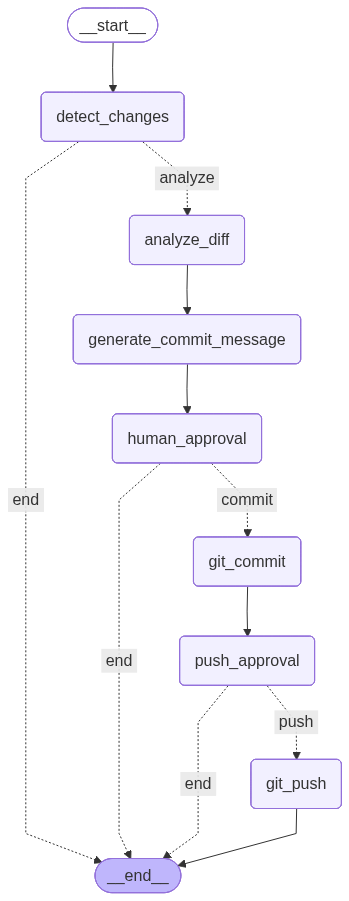

In [7]:
graph

## Text-Based Workflow Diagram

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════╗
║           AI GIT AUTOMATION AGENT WORKFLOW                     ║
║              (Dual Human-in-the-Loop)                          ║
╚════════════════════════════════════════════════════════════════╝

                        START
                          ↓
                  🔍 detect_changes
                          ↓
                ┌─────────┴─────────┐
          has_changes?          no changes
                ↓                   ↓
          📊 analyze_diff          END
                ↓
       🤖 generate_commit_message
                ↓
       ✋ human_approval (commit?)
                ↓
          ┌─────┴─────┐
      approved?    rejected
          ↓            ↓
     💾 git_commit    END
          ↓
     ✋ push_approval (push?)
          ↓
          ┌─────┴─────┐
      approved?    rejected
          ↓            ↓
     🚀 git_push     END
          ↓
         END
""")

## Workflow Summary

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════╗
║ WORKFLOW NODES:                                                ║
╠════════════════════════════════════════════════════════════════╣
║ 1. detect_changes          - Check for uncommitted changes    ║
║ 2. analyze_diff            - Read git diff                    ║
║ 3. generate_commit_message - AI generates commit message      ║
║ 4. human_approval          - User approves/edits message      ║
║ 5. git_commit              - Commit changes locally           ║
║ 6. push_approval           - User approves push               ║
║ 7. git_push                - Push to remote repository        ║
╚════════════════════════════════════════════════════════════════╝

╔════════════════════════════════════════════════════════════════╗
║ DECISION POINTS:                                               ║
╠════════════════════════════════════════════════════════════════╣
║ • No changes detected      → END                               ║
║ • Commit rejected          → END (no commit)                   ║
║ • Push rejected            → END (committed locally only)      ║
║ • All approved             → Complete workflow                 ║
╚════════════════════════════════════════════════════════════════╝
""")

## Run the Workflow (Demo)

In [ ]:
# Initial state
initial_state = {
    "has_changes": False,
    "diff": "",
    "commit_message": "",
    "approved": False,
    "committed": False,
    "push_approved": False,
    "pushed": False,
    "error": ""
}

print("🚀 Running the graph...\n")
print("="*70)

# Execute the graph
result = graph.invoke(initial_state)

print("="*70)
print("\n📋 Final State:")
for key, value in result.items():
    print(f"  {key}: {value}")

print("\n✅ Workflow completed successfully!")

## Mermaid Diagram

Copy the code below and paste it into https://mermaid.live to see a beautiful graph visualization.

In [ ]:
mermaid_code = """
graph TD
    START([START]) --> A[🔍 detect_changes]
    A -->|has changes| B[📊 analyze_diff]
    A -->|no changes| END1([END])
    B --> C[🤖 generate_commit_message]
    C --> D[✋ human_approval]
    D -->|approved| E[💾 git_commit]
    D -->|rejected| END2([END])
    E --> F[✋ push_approval]
    F -->|approved| G[🚀 git_push]
    F -->|rejected| END3([END])
    G --> END4([END])
    
    style START fill:#90EE90
    style END1 fill:#FFB6C1
    style END2 fill:#FFB6C1
    style END3 fill:#FFB6C1
    style END4 fill:#90EE90
    style D fill:#FFD700
    style F fill:#FFD700
"""

print("Copy this to https://mermaid.live:\n")
print(mermaid_code)

## Summary

This notebook demonstrates the complete LangGraph workflow for the AI Git Automation Agent:

**Key Features:**
- 7 nodes orchestrating the automation
- 2 human approval checkpoints (commit and push)
- 3 conditional branches for different scenarios
- Full control over the automation process

**Benefits:**
- Commit locally without pushing
- Edit AI-generated messages
- Review before exposing changes
- Abort at any stage